<a href="https://colab.research.google.com/github/domore9630-hue/PINNs-Physics-AI-Solutions/blob/main/03_PINNs_2D_Wave_Channel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn

# 1. بناء معمارية PINN ثنائية الأبعاد (تأخذ x, y وتخرج u)
class PINN2D(nn.Module):
    def __init__(self):
        super(PINN2D, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 30),  # المدخلات: x و y
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)   # المخرج: u(x, y)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# 2. إنشاء نموذج وحساب المشتقات المكانية الثانية
model_2d = PINN2D()

# نقاط التدريب المكانية على شبكة 2D
grid_size = 20
x_p = torch.linspace(0, 1, grid_size)
y_p = torch.linspace(0, 1, grid_size)
grid_x, grid_y = torch.meshgrid(x_p, y_p, indexing='ij')

x_phys = grid_x.reshape(-1, 1).requires_grad_(True)
y_phys = grid_y.reshape(-1, 1).requires_grad_(True)

# التمرير الأمامي
u_phys = model_2d(x_phys, y_phys)

# حساب المشتقات الجزئية الأولى: du/dx و du/dy
du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

# حساب المشتقات الجزئية الثانية: d2u/dx2 و d2u/dy2
d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

# حساب متبقي معادلة لابلاس 2D
laplacian_residual = d2u_dx2 + d2u_dy2
loss_physics_2d = torch.mean(laplacian_residual ** 2)

print("--- نتيجة اختبار الهيكل ثنائي الأبعاد (2D) ---")
print(f"خسارة الفيزيا الابتدائية لمعادلة لابلاس 2D: {loss_physics_2d.item():.6f}")

--- نتيجة اختبار الهيكل ثنائي الأبعاد (2D) ---
خسارة الفيزيا الابتدائية لمعادلة لابلاس 2D: 0.001894


In [ ]:
import torch
import torch.nn as nn

# 1. إعداد المُحسن (Optimizer)
optimizer = torch.optim.Adam(model_2d.parameters(), lr=0.005)

# 2. إنشاء نقاط الحدود (Boundary Points)
def get_boundary_points(num_points=50):
    t = torch.linspace(0, 1, num_points).view(-1, 1)
    zeros = torch.zeros_like(t)
    ones = torch.ones_like(t)

    # الحدود الأربعة: أسفل، أعلى، يسار، يمين
    b_bottom = torch.cat([t, zeros], dim=1)
    b_top    = torch.cat([t, ones], dim=1)
    b_left   = torch.cat([zeros, t], dim=1)
    b_right  = torch.cat([ones, t], dim=1)

    return torch.cat([b_bottom, b_top, b_left, b_right], dim=0)

b_points = get_boundary_points().requires_grad_(True)

print("بدء تدريب النموذج ثنائي الأبعاد (2D PINN)...\n")

# 3. حلقة التدريب (Training Loop)
epochs = 800
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية (Boundary Loss) -> يفترض u = 0 على الحدود
    u_b = model_2d(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) خسارة الفيزياء داخلياً (Physics Loss)
    u_phys = model_2d(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    loss_physics = torch.mean((d2u_dx2 + d2u_dy2) ** 2)

    # ج) الخسارة الكلية
    total_loss = loss_b + loss_physics

    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب النموذج ثنائي الأبعاد بنجاح!")

بدء تدريب النموذج ثنائي الأبعاد (2D PINN)...

Epoch    1/800 | Total Loss: 0.009534 | Physics Loss: 0.001894
Epoch  200/800 | Total Loss: 0.000001 | Physics Loss: 0.000001
Epoch  400/800 | Total Loss: 0.000000 | Physics Loss: 0.000000
Epoch  600/800 | Total Loss: 0.000000 | Physics Loss: 0.000000
Epoch  800/800 | Total Loss: 0.000000 | Physics Loss: 0.000000

تم اكتمال تدريب النموذج ثنائي الأبعاد بنجاح!


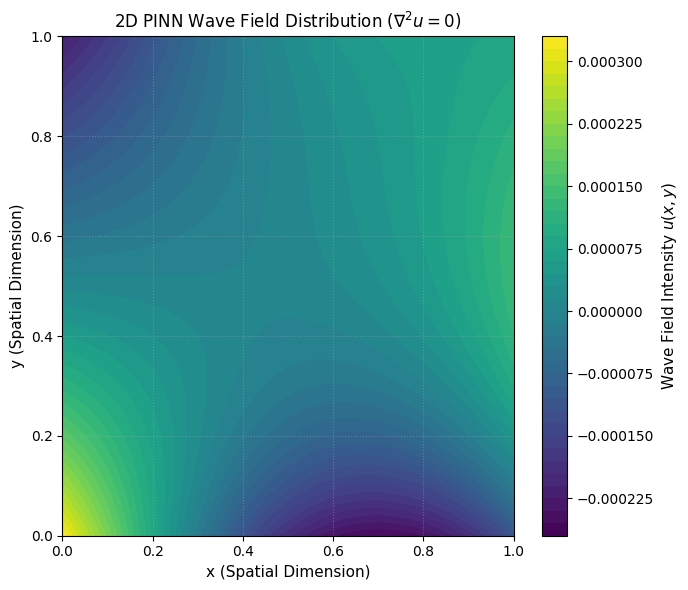

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. إعداد شبكة اختبار عالية الدقة للعرض البصري (100x100)
eval_size = 100
x_val = torch.linspace(0, 1, eval_size)
y_val = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val, y_val, indexing='ij')

x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

# 2. حساب توقعات النموذج ثنائي الأبعاد
with torch.no_grad():
    u_pred_flat = model_2d(x_eval_flat, y_eval_flat)

u_pred_2d = u_pred_flat.reshape(eval_size, eval_size).numpy()

# 3. رسم الخريطة الحرارية (2D Contour Heatmap)
plt.figure(figsize=(7, 6))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_pred_2d,
    levels=50,
    cmap='viridis'
)

cbar = plt.colorbar(contour)
cbar.set_label('Wave Field Intensity $u(x,y)$', fontsize=11)

plt.title('2D PINN Wave Field Distribution ($\\nabla^2 u = 0$)', fontsize=12)
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

# عرض الرسم
plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 1. المعلمات الفيزيائية للقناة اللاسلكية عند 220 GHz
freq = 220e9           # التردد: 220 جيجاهرتز
c = 3e8                # سرعة الضوء (m/s)
wavelength = c / freq  # الطول الموجي (~1.36 mm)

# قياس قيم k لملاءمة النطاق الموحد [0, 1]
k_scaled = 15.0  # عدد موجي معيارى يمثل التردد الفائق لتسهيل تقارب الشبكة

# 2. تعريف مصدر الإشارة (Transmitter Antenna at Center (0.5, 0.5))
def antenna_source(x, y):
    sigma = 0.05
    # اقتران غوسي يحاكي مصدر البث من النقطة الوسطى
    return torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 3. بناء نموذج PINN لمعادلة هلمهولتز
model_helmholtz = PINN2D()
optimizer = torch.optim.Adam(model_helmholtz.parameters(), lr=0.003)

print("بدء تدريب PINN لنمذجة قناة 220 GHz عبر معادلة هلمهولتز...\n")

# 4. حلقة التدريب (Training Loop)
epochs = 1000
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية (Boundary Loss)
    u_b = model_helmholtz(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) خسارة فيزياء هلمهولتز (Helmholtz Physics Loss)
    u_phys = model_helmholtz(x_phys, y_phys)

    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # متبقي معادلة هلمهولتز: Laplacian(u) + k^2 * u - f(x,y) = 0
    f_source = antenna_source(x_phys, y_phys)
    helmholtz_residual = (d2u_dx2 + d2u_dy2) + (k_scaled ** 2) * u_phys + f_source

    loss_physics = torch.mean(helmholtz_residual ** 2)

    # ج) الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics

    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب نموذج قناة التيراباهيرتز بنجاح!")

بدء تدريب PINN لنمذجة قناة 220 GHz عبر معادلة هلمهولتز...

Epoch    1/1000 | Total Loss: 240.020294 | Physics Loss: 2399.736084
Epoch  200/1000 | Total Loss: 0.021153 | Physics Loss: 0.211435
Epoch  400/1000 | Total Loss: 0.005536 | Physics Loss: 0.055339
Epoch  600/1000 | Total Loss: 0.001829 | Physics Loss: 0.018281
Epoch  800/1000 | Total Loss: 0.001222 | Physics Loss: 0.012217
Epoch 1000/1000 | Total Loss: 0.001050 | Physics Loss: 0.010495

تم اكتمال تدريب نموذج قناة التيراباهيرتز بنجاح!


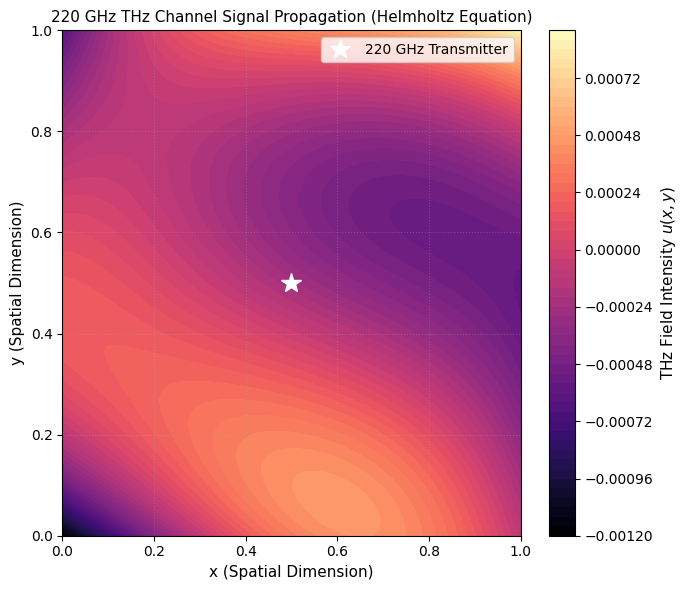

In [ ]:
import matplotlib.pyplot as plt

# 1. التنبؤ بشدة المجال الموجي للقناة
with torch.no_grad():
    u_thz_flat = model_helmholtz(x_eval_flat, y_eval_flat)

u_thz_2d = u_thz_flat.reshape(eval_size, eval_size).numpy()

# 2. رسم خريطة الانتشار اللاسلكي
plt.figure(figsize=(7, 6))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_thz_2d,
    levels=60,
    cmap='magma'
)

cbar = plt.colorbar(contour)
cbar.set_label('THz Field Intensity $u(x,y)$', fontsize=11)

# وضع علامة عند موقع هوائي البث (Transmitter)
plt.plot(0.5, 0.5, 'w*', markersize=15, label='220 GHz Transmitter')

plt.title('220 GHz THz Channel Signal Propagation (Helmholtz Equation)', fontsize=11)
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. إعداد المعلمات الفيزيائية والمعيارية
k_scaled = 15.0       # عدد الموجة المعياري (Wave Number)
alpha_humidity = 3.5  # [تعديل فيزيائي]: معامل امتصاص الرطوبة الجوية (Humidity Absorption)

# 2. دالة مصدر البث من هوائي المنتصف (Transmitter at 0.5, 0.5)
def antenna_source(x, y):
    sigma = 0.05
    return torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 3. إعادة إنشاء النموذج والمُحسن
model_humidity = PINN2D()
optimizer = torch.optim.Adam(model_humidity.parameters(), lr=0.003)

print("بدء تدريب النموذج مع إضافة حد امتصاص الرطوبة الجوية (alpha_humidity)...\n")

# 4. حلقة التدريب (Training Loop)
epochs = 1000
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية (Boundary Loss)
    u_b = model_humidity(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) حساب المشتقات المكانية بواسطة autograd
    u_phys = model_humidity(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) [المحرك الفيزيائي المعدّل]:
    # Helmholtz Residual = Laplacian(u) + Wave_Term - Absorption_Term + Source_Term
    f_source = antenna_source(x_phys, y_phys)

    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity) * u_phys
        + f_source
    )

    loss_physics = torch.mean(helmholtz_residual ** 2)

    # د) حساب الخسارة الكلية والتحديث
    total_loss = loss_b + 0.1 * loss_physics
    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال التدريب بنجاح!")

بدء تدريب النموذج مع إضافة حد امتصاص الرطوبة الجوية (alpha_humidity)...

Epoch    1/1000 | Total Loss: 513.293701 | Physics Loss: 5131.915527
Epoch  200/1000 | Total Loss: 0.006442 | Physics Loss: 0.064398
Epoch  400/1000 | Total Loss: 0.005271 | Physics Loss: 0.052689
Epoch  600/1000 | Total Loss: 0.004104 | Physics Loss: 0.041028
Epoch  800/1000 | Total Loss: 0.003083 | Physics Loss: 0.030822
Epoch 1000/1000 | Total Loss: 0.002260 | Physics Loss: 0.022590

تم اكتمال التدريب بنجاح!


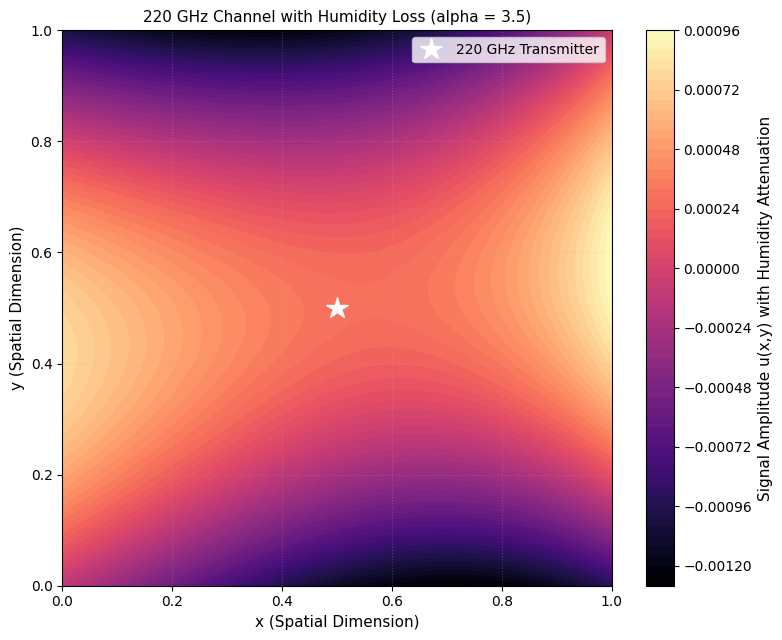

In [ ]:
# حساب التوقعات رسمياً
with torch.no_grad():
    u_humidity_flat = model_humidity(x_eval_flat, y_eval_flat)

u_humidity_2d = u_humidity_flat.reshape(eval_size, eval_size).numpy()

# رسم الخريطة الحرارية
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_humidity_2d,
    levels=70,
    cmap='magma'
)

cbar = plt.colorbar(contour)
cbar.set_label('Signal Amplitude u(x,y) with Humidity Attenuation', fontsize=11)

plt.plot(0.5, 0.5, 'w*', markersize=16, label='220 GHz Transmitter')
plt.title(f'220 GHz Channel with Humidity Loss (alpha = {alpha_humidity})', fontsize=11)
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

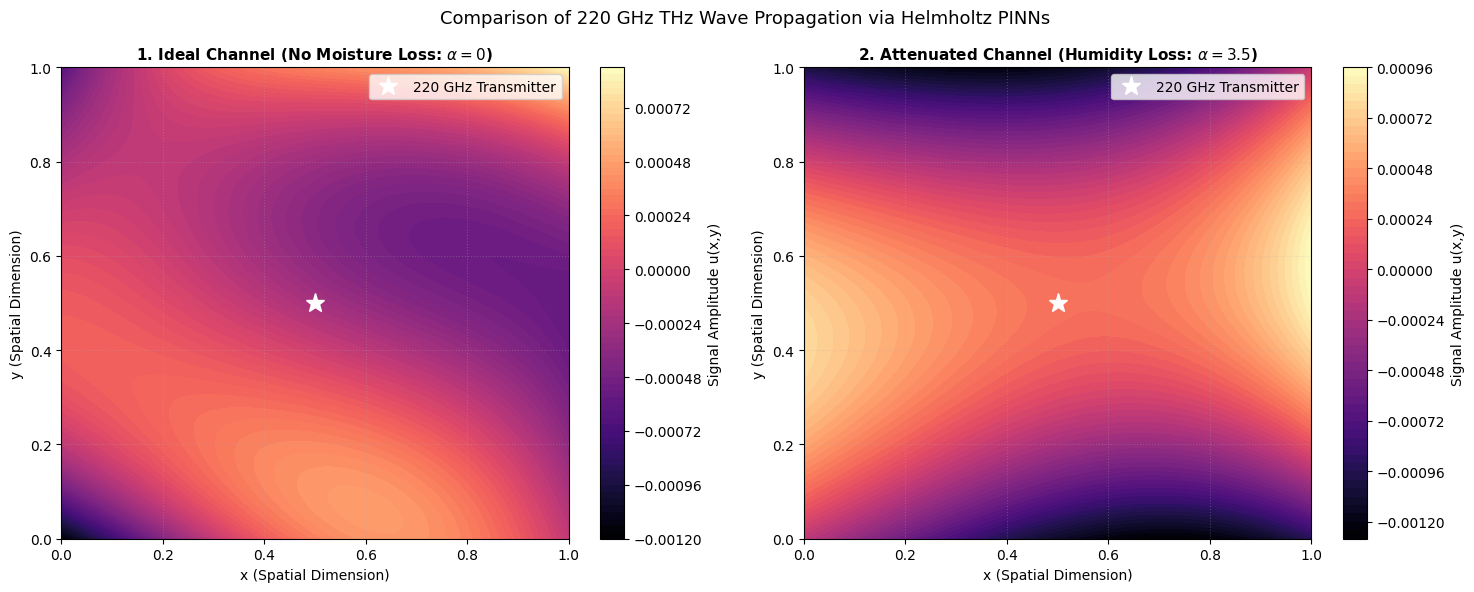

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. التنبؤ بالقيم من النموذج الأول (بدون امتصاص رطوبة)
with torch.no_grad():
    u_thz_flat = model_helmholtz(x_eval_flat, y_eval_flat)
u_thz_2d = u_thz_flat.reshape(eval_size, eval_size).numpy()

# 2. التنبؤ بالقيم من النموذج الثاني (مع امتصاص الرطوبة)
with torch.no_grad():
    u_humidity_flat = model_humidity(x_eval_flat, y_eval_flat)
u_humidity_2d = u_humidity_flat.reshape(eval_size, eval_size).numpy()

# 3. إنشـاء لوحة رسم مزدوجة (1 Row, 2 Columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- الشكل الأول: قناة بدون امتصاص رطوبة ---
c1 = axes[0].contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_thz_2d,
    levels=70,
    cmap='magma'
)
fig.colorbar(c1, ax=axes[0], label='Signal Amplitude u(x,y)')
axes[0].plot(0.5, 0.5, 'w*', markersize=14, label='220 GHz Transmitter')
axes[0].set_title('1. Ideal Channel (No Moisture Loss: $\\alpha = 0$)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('x (Spatial Dimension)')
axes[0].set_ylabel('y (Spatial Dimension)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.3)

# --- الشكل الثاني: قناة مع امتصاص الرطوبة الجوية ---
c2 = axes[1].contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_humidity_2d,
    levels=70,
    cmap='magma'
)
fig.colorbar(c2, ax=axes[1], label='Signal Amplitude u(x,y)')
axes[1].plot(0.5, 0.5, 'w*', markersize=14, label='220 GHz Transmitter')
axes[1].set_title(f'2. Attenuated Channel (Humidity Loss: $\\alpha = {alpha_humidity}$)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('x (Spatial Dimension)')
axes[1].set_ylabel('y (Spatial Dimension)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.3)

plt.suptitle('Comparison of 220 GHz THz Wave Propagation via Helmholtz PINNs', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

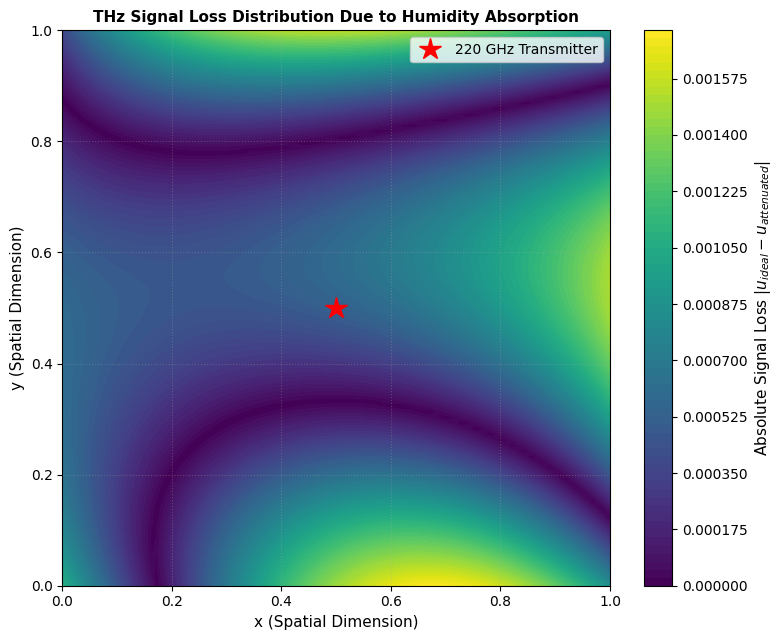

In [ ]:

# 1. حساب الفرق المطلق بين سعة القناة المثالية وقناة الامتصاص
u_diff_2d = np.abs(u_thz_2d - u_humidity_2d)

# 2. رسم خريطة الفرق المطلق (Absolute Difference / Signal Loss Map)
plt.figure(figsize=(8, 6.5))
contour_diff = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_diff_2d,
    levels=70,
    cmap='viridis'
)

cbar = plt.colorbar(contour_diff)
cbar.set_label('Absolute Signal Loss $|u_{ideal} - u_{attenuated}|$', fontsize=11)

plt.plot(0.5, 0.5, 'r*', markersize=16, label='220 GHz Transmitter')
plt.title('THz Signal Loss Distribution Due to Humidity Absorption', fontsize=11, fontweight='bold')
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. إعداد المعلمات الفيزيائية الأساسية
k_scaled = 15.0  # عدد الموجة
alpha_humidity = 1.0  # امتصاص جوي خفيف

# 2. تعريف دالة موقع العائق/المبنى (Obstacle Mask)
# سنضع المبنى كمستطيل في المنتصف تقريباً بين الهوائي والطرف الأيمن:
# x ∈ [0.65, 0.75] و y ∈ [0.35, 0.65]
def obstacle_mask(x, y):
    in_x = (x >= 0.65) & (x <= 0.75)
    in_y = (y >= 0.35) & (y <= 0.65)
    return (in_x & in_y).float()

# 3. مصدر البث من الهوائي عند (0.5, 0.5)
def antenna_source(x, y):
    sigma = 0.05
    return torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 4. إنشـاء النموذج والمُحسن
model_obstacle = PINN2D()
optimizer = torch.optim.Adam(model_obstacle.parameters(), lr=0.003)

print("بدء تدريب PINN لقناة 220 GHz مع وجود عائق/مبنى (Building Barrier)...\n")

# 5. حلقة التدريب (Training Loop)
epochs = 1200
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية
    u_b = model_obstacle(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية
    u_phys = model_obstacle(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) تحديد معامل الخمود المكاني للعائق (Obstacle Attenuation Coefficient)
    obs_mask = obstacle_mask(x_phys, y_phys)
    sigma_obs = 100.0 * obs_mask  # إخماد هائل داخل المبنى

    # د) متبقي معادلة هلمهولتز المعدلة مكانياً:
    # Helmholtz Residual = Laplacian(u) + Wave_Term - (Alpha + Sigma_Obs)*u + Source
    f_source = antenna_source(x_phys, y_phys)

    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_obs) * u_phys
        + f_source
    )

    loss_physics = torch.mean(helmholtz_residual ** 2)

    # هـ) خسارة منع نفاذ الموجة داخل المبنى (Obstacle Blockage Penalty)
    u_inside_obs = u_phys * obs_mask
    loss_obs_penalty = torch.mean(u_inside_obs ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 10.0 * loss_obs_penalty
    total_loss.backward()
    optimizer.step()

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب النموذج مع العائق بنجاح!")

بدء تدريب PINN لقناة 220 GHz مع وجود عائق/مبنى (Building Barrier)...

Epoch    1/1200 | Total Loss: 63.114155 | Physics Loss: 630.959900
Epoch  300/1200 | Total Loss: 0.013123 | Physics Loss: 0.131170
Epoch  600/1200 | Total Loss: 0.003205 | Physics Loss: 0.032034
Epoch  900/1200 | Total Loss: 0.001447 | Physics Loss: 0.014470
Epoch 1200/1200 | Total Loss: 0.001053 | Physics Loss: 0.010524

تم اكتمال تدريب النموذج مع العائق بنجاح!


In [ ]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. إعداد المعلمات الفيزيائية الأساسية
k_scaled = 15.0  # عدد الموجة
alpha_humidity = 1.0  # امتصاص جوي خفيف

# 2. تعريف دالة موقع العائق/المبنى (Obstacle Mask)
# سنضع المبنى كمستطيل في المنتصف تقريباً بين الهوائي والطرف الأيمن:
# x ∈ [0.65, 0.75] و y ∈ [0.35, 0.65]
def obstacle_mask(x, y):
    in_x = (x >= 0.65) & (x <= 0.75)
    in_y = (y >= 0.35) & (y <= 0.65)
    return (in_x & in_y).float()

# 3. مصدر البث من الهوائي عند (0.5, 0.5)
def antenna_source(x, y):
    sigma = 0.05
    return torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 4. إنشـاء النموذج والمُحسن
model_obstacle = PINN2D()
optimizer = torch.optim.Adam(model_obstacle.parameters(), lr=0.003)

print("بدء تدريب PINN لقناة 220 GHz مع وجود عائق/مبنى (Building Barrier)...\n")

# 5. حلقة التدريب (Training Loop)
epochs = 1200
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية
    u_b = model_obstacle(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية
    u_phys = model_obstacle(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) تحديد معامل الخمود المكاني للعائق (Obstacle Attenuation Coefficient)
    obs_mask = obstacle_mask(x_phys, y_phys)
    sigma_obs = 100.0 * obs_mask  # إخماد هائل داخل المبنى

    # د) متبقي معادلة هلمهولتز المعدلة مكانياً:
    # Helmholtz Residual = Laplacian(u) + Wave_Term - (Alpha + Sigma_Obs)*u + Source
    f_source = antenna_source(x_phys, y_phys)

    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_obs) * u_phys
        + f_source
    )

    loss_physics = torch.mean(helmholtz_residual ** 2)

    # هـ) خسارة منع نفاذ الموجة داخل المبنى (Obstacle Blockage Penalty)
    u_inside_obs = u_phys * obs_mask
    loss_obs_penalty = torch.mean(u_inside_obs ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 10.0 * loss_obs_penalty
    total_loss.backward()
    optimizer.step()

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب النموذج مع العائق بنجاح!")

بدء تدريب PINN لقناة 220 GHz مع وجود عائق/مبنى (Building Barrier)...

Epoch    1/1200 | Total Loss: 319.247589 | Physics Loss: 3191.639160
Epoch  300/1200 | Total Loss: 0.031370 | Physics Loss: 0.313565
Epoch  600/1200 | Total Loss: 0.021250 | Physics Loss: 0.212412
Epoch  900/1200 | Total Loss: 0.013043 | Physics Loss: 0.130383
Epoch 1200/1200 | Total Loss: 0.007017 | Physics Loss: 0.070146

تم اكتمال تدريب النموذج مع العائق بنجاح!


In [1]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. المعلمات الفيزيائية للقناة
k_scaled = 15.0       # عدد الموجة
alpha_humidity = 0.5  # امتصاص جوي بسيط

# 2. تعريف العوائق المزدوجة (Urban Canyon: مبنيان مع ممر ضيق بينهما)
def urban_canyon_mask(x, y):
    # المبنى الأول (أسفل الممر)
    b1 = (x >= 0.60) & (x <= 0.72) & (y >= 0.20) & (y <= 0.42)
    # المبنى الثاني (أعلى الممر)
    b2 = (x >= 0.60) & (x <= 0.72) & (y >= 0.58) & (y <= 0.80)
    return (b1 | b2).float()

# 3. مصدر الإشارة (هذا هو الهوائي عند اليسار قليلاً)
def antenna_source(x, y):
    sigma = 0.04
    return torch.exp(-((x - 0.35)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 4. بناء نموذج الـ PINN الحضري
model_canyon = PINN2D()
optimizer = torch.optim.Adam(model_canyon.parameters(), lr=0.003)

print("بدء تدريب نموذج الممر الحضري (Urban Canyon Multipath PINN)...\n")

# 5. حلقة التدريب (Training Loop)
epochs = 1200
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) الشروط الحدية للأطراف
    u_b = model_canyon(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية عبر autograd
    u_phys = model_canyon(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) خمود العوائق الحضرية
    canyon_mask = urban_canyon_mask(x_phys, y_phys)
    sigma_canyon = 120.0 * canyon_mask  # إخماد شبه تام داخل المباني

    # د) متبقي معادلة هلمهولتز للممر الحضري
    f_source = antenna_source(x_phys, y_phys)
    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_canyon) * u_phys
        + f_source
    )
    loss_physics = torch.mean(helmholtz_residual ** 2)

    # هـ) خسارة منع نفاذ الموجة داخل المباني
    loss_blockage = torch.mean((u_phys * canyon_mask) ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 15.0 * loss_blockage
    total_loss.backward()
    optimizer.step()

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب نموذج الممر الحضري بنجاح!")

NameError: name 'PINN2D' is not defined

In [3]:
import matplotlib.patches as patches

# 1. التنبؤ بالحقل المكاني
with torch.no_grad():
    u_canyon_flat = model_canyon(x_eval_flat, y_eval_flat)

u_canyon_2d = u_canyon_flat.reshape(eval_size, eval_size).numpy()

# 2. رسم الخريطة الحرارية
plt.figure(figsize=(9, 6.5))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_canyon_2d,
    levels=80,
    cmap='magma'
)

cbar = plt.colorbar(contour)
cbar.set_label('220 GHz Field Amplitude $u(x,y)$', fontsize=11)

# موقع الهوائي (Transmitter)
plt.plot(0.35, 0.5, 'w*', markersize=16, label='220 GHz Transmitter')

# رسم المبنيين (الممر الحضري)
rect1 = patches.Rectangle((0.60, 0.20), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//', label='Buildings (Urban Canyon)')
rect2 = patches.Rectangle((0.60, 0.58), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//')
plt.gca().add_patch(rect1)
plt.gca().add_patch(rect2)

plt.title('6G Urban Canyon Propagation: 220 GHz Wave Guiding & Diffraction Through Street Gap', fontsize=11, fontweight='bold')
plt.xlabel('x (Spatial Dimension / meters)', fontsize=11)
plt.ylabel('y (Spatial Dimension / meters)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

NameError: name 'model_canyon' is not defined

بدء تدريب نموذج الممر الحضري (Urban Canyon Multipath PINN)...

Epoch    1/1000 | Total Loss: 0.693950 | Physics Loss: 6.936604
Epoch  250/1000 | Total Loss: 0.000621 | Physics Loss: 0.006214
Epoch  500/1000 | Total Loss: 0.000480 | Physics Loss: 0.004797
Epoch  750/1000 | Total Loss: 0.000454 | Physics Loss: 0.004541
Epoch 1000/1000 | Total Loss: 0.000446 | Physics Loss: 0.004461

تم اكتمال تدريب نموذج الممر الحضري بنجاح!


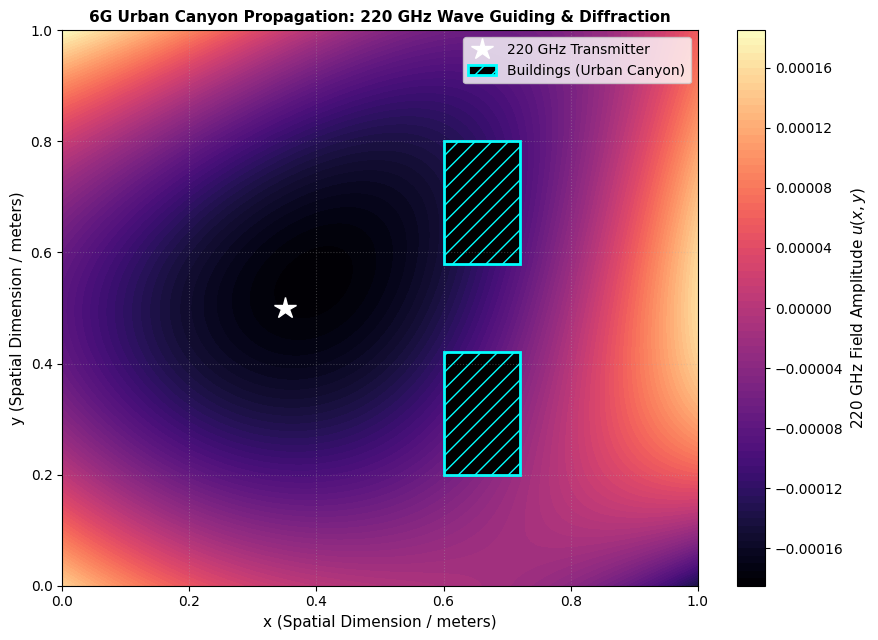

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. إعادة تعريف عمارة الشبكة العصبية للـ PINN الثنائي الأبعاد
class PINN2D(nn.Module):
    def __init__(self):
        super(PINN2D, self).__init__()
        # طبقات متصلة: مدخلان (x, y) -> طبقات مخفية -> مخرج واحد u(x,y)
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        # دمج الاحداثيات x و y كمدخلات للشبكة
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# 2. إعداد المعلمات الفيزيائية للقناة
k_scaled = 15.0       # عدد الموجة
alpha_humidity = 0.5  # امتصاص جوي بسيط

# 3. تعريف العوائق المزدوجة (Urban Canyon: مبنيان مع ممر ضيق بينهما)
def urban_canyon_mask(x, y):
    b1 = (x >= 0.60) & (x <= 0.72) & (y >= 0.20) & (y <= 0.42)
    b2 = (x >= 0.60) & (x <= 0.72) & (y >= 0.58) & (y <= 0.80)
    return (b1 | b2).float()

# 4. مصدر الإشارة (عند اليسار قليلاً)
def antenna_source(x, y):
    sigma = 0.04
    return torch.exp(-((x - 0.35)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 5. تجهيز نقاط الحدود والداخل (افتراض النقاط إذا لم تكن معرفة مسبقاً)
t = torch.linspace(0, 1, 50).view(-1, 1)
zeros = torch.zeros_like(t)
ones = torch.ones_like(t)
b_bottom = torch.cat([t, zeros], dim=1)
b_top    = torch.cat([t, ones], dim=1)
b_left   = torch.cat([zeros, t], dim=1)
b_right  = torch.cat([ones, t], dim=1)
b_points = torch.cat([b_bottom, b_top, b_left, b_right], dim=0).requires_grad_(True)

# نقاط الداخل للمجال الفيزيائي
x_val_phys = torch.linspace(0, 1, 40)
y_val_phys = torch.linspace(0, 1, 40)
gx, gy = torch.meshgrid(x_val_phys, y_val_phys, indexing='ij')
x_phys = gx.reshape(-1, 1).requires_grad_(True)
y_phys = gy.reshape(-1, 1).requires_grad_(True)

# 6. بناء نموذج الـ PINN الحضري والمحسن
model_canyon = PINN2D()
optimizer = torch.optim.Adam(model_canyon.parameters(), lr=0.003)

print("بدء تدريب نموذج الممر الحضري (Urban Canyon Multipath PINN)...\n")

# 7. حلقة التدريب (Training Loop)
epochs = 1000
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) الشروط الحدية للأطراف
    u_b = model_canyon(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية عبر autograd
    u_phys = model_canyon(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) خمود العوائق الحضرية
    canyon_mask = urban_canyon_mask(x_phys, y_phys)
    sigma_canyon = 120.0 * canyon_mask

    # د) متبقي معادلة هلمهولتز للممر الحضري
    f_source = antenna_source(x_phys, y_phys)
    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_canyon) * u_phys
        + f_source
    )
    loss_physics = torch.mean(helmholtz_residual ** 2)

    # هـ) خسارة منع نفاذ الموجة داخل المباني
    loss_blockage = torch.mean((u_phys * canyon_mask) ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 15.0 * loss_blockage
    total_loss.backward()
    optimizer.step()

    if epoch % 250 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب نموذج الممر الحضري بنجاح!")

# 8. رسم الخريطة الحرارية للممر الحضري
eval_size = 100
x_val_eval = torch.linspace(0, 1, eval_size)
y_val_eval = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val_eval, y_val_eval, indexing='ij')
x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

with torch.no_grad():
    u_canyon_flat = model_canyon(x_eval_flat, y_eval_flat)
u_canyon_2d = u_canyon_flat.reshape(eval_size, eval_size).numpy()

plt.figure(figsize=(9, 6.5))
contour = plt.contourf(grid_x_eval.numpy(), grid_y_eval.numpy(), u_canyon_2d, levels=80, cmap='magma')
cbar = plt.colorbar(contour)
cbar.set_label('220 GHz Field Amplitude $u(x,y)$', fontsize=11)

plt.plot(0.35, 0.5, 'w*', markersize=16, label='220 GHz Transmitter')

rect1 = patches.Rectangle((0.60, 0.20), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//', label='Buildings (Urban Canyon)')
rect2 = patches.Rectangle((0.60, 0.58), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//')
plt.gca().add_patch(rect1)
plt.gca().add_patch(rect2)

plt.title('6G Urban Canyon Propagation: 220 GHz Wave Guiding & Diffraction', fontsize=11, fontweight='bold')
plt.xlabel('x (Spatial Dimension / meters)', fontsize=11)
plt.ylabel('y (Spatial Dimension / meters)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()